# ⚡ Chương 4 — Dataset 3: Energy Consumption — LSTM + Attention
## Kỹ thuật: Custom Attention Layer + LSTM + Attention Weight Heatmap

**Pipeline:** EDA → Seasonality Analysis → LSTM+Attention → Train → Attention Visualization

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import glob, os, warnings

import random

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.titlesize': 13, 'axes.titleweight': 'bold'})

DATA_DIR   = '../data/energy_consumption'
SAVE_DIR   = '../results/energy_attention'
os.makedirs(SAVE_DIR, exist_ok=True)

LOOK_BACK  = 48    # 48 bước thời gian
EPOCHS     = 40
BATCH_SIZE = 64

print(f'TF: {tf.__version__}')

2026-05-09 20:28:50.874044: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-09 20:28:50.901935: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-09 20:28:51.357868: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


TF: 2.13.0


## 📂 1. Load Data

In [15]:
csv_files=glob.glob(f'{DATA_DIR}/**/*.csv',recursive=True)+glob.glob(f'{DATA_DIR}/*.csv')
print('Found:',csv_files)

# lấy file lớn nhất
df=pd.read_csv(sorted(csv_files,key=os.path.getsize,reverse=True)[0])

# parse datetime
df['Datetime']=pd.to_datetime(df['Datetime'])
df=df.sort_values('Datetime').reset_index(drop=True)

# xử lý NaN
df=df.ffill().bfill()

print('Shape:',df.shape)
print('Columns:',list(df.columns))
print('\nMissing values:\n',df.isna().sum())

df.head()

Found: ['../data/energy_consumption/NI_hourly.csv', '../data/energy_consumption/EKPC_hourly.csv', '../data/energy_consumption/pjm_hourly_est.csv', '../data/energy_consumption/FE_hourly.csv', '../data/energy_consumption/PJM_Load_hourly.csv', '../data/energy_consumption/PJME_hourly.csv', '../data/energy_consumption/AEP_hourly.csv', '../data/energy_consumption/DEOK_hourly.csv', '../data/energy_consumption/DOM_hourly.csv', '../data/energy_consumption/DAYTON_hourly.csv', '../data/energy_consumption/COMED_hourly.csv', '../data/energy_consumption/DUQ_hourly.csv', '../data/energy_consumption/PJMW_hourly.csv', '../data/energy_consumption/NI_hourly.csv', '../data/energy_consumption/EKPC_hourly.csv', '../data/energy_consumption/pjm_hourly_est.csv', '../data/energy_consumption/FE_hourly.csv', '../data/energy_consumption/PJM_Load_hourly.csv', '../data/energy_consumption/PJME_hourly.csv', '../data/energy_consumption/AEP_hourly.csv', '../data/energy_consumption/DEOK_hourly.csv', '../data/energy_consu

,Datetime,AEP,COMED,DAYTON,DEOK,DOM,DUQ,EKPC,FE,NI,PJME,PJMW,PJM_Load
0,1998-04-01 01:00:00,12379.0,9631.0,1621.0,2533.0,7190.0,1364.0,1166.0,0.0,9198.0,30393.0,4374.0,22259.0
1,1998-04-01 02:00:00,12379.0,9631.0,1621.0,2533.0,7190.0,1364.0,1166.0,0.0,9198.0,30393.0,4374.0,21244.0
2,1998-04-01 03:00:00,12379.0,9631.0,1621.0,2533.0,7190.0,1364.0,1166.0,0.0,9198.0,30393.0,4374.0,20651.0
3,1998-04-01 04:00:00,12379.0,9631.0,1621.0,2533.0,7190.0,1364.0,1166.0,0.0,9198.0,30393.0,4374.0,20421.0
4,1998-04-01 05:00:00,12379.0,9631.0,1621.0,2533.0,7190.0,1364.0,1166.0,0.0,9198.0,30393.0,4374.0,20713.0


In [3]:
# Detect target (energy/MW/consumption)
energy_cols = [c for c in df.columns if any(k in c.lower()
               for k in ['mw','energy','consumption','kwh','load','demand'])]
TARGET_COL = energy_cols[0] if energy_cols else df.select_dtypes(include=np.number).columns[0]
print(f'Target column: {TARGET_COL}')

# Parse datetime if available
date_cols = [c for c in df.columns if any(k in c.lower() for k in ['date','time','datetime'])]
if date_cols:
    df[date_cols[0]] = pd.to_datetime(df[date_cols[0]], errors='coerce')
    df = df.dropna(subset=[date_cols[0]]).sort_values(date_cols[0]).reset_index(drop=True)

df = df.dropna(subset=[TARGET_COL])
data_series = df[TARGET_COL].values.astype(float)
print(f'Total time steps: {len(data_series):,}')

# Limit to last 20000 for speed
if len(data_series) > 20000:
    data_series = data_series[-20000:]
    print(f'Trimmed to last 20,000 steps')

Target column: PJMW
Total time steps: 143,206
Trimmed to last 20,000 steps


## 📊 2. EDA — Seasonality & Pattern Analysis

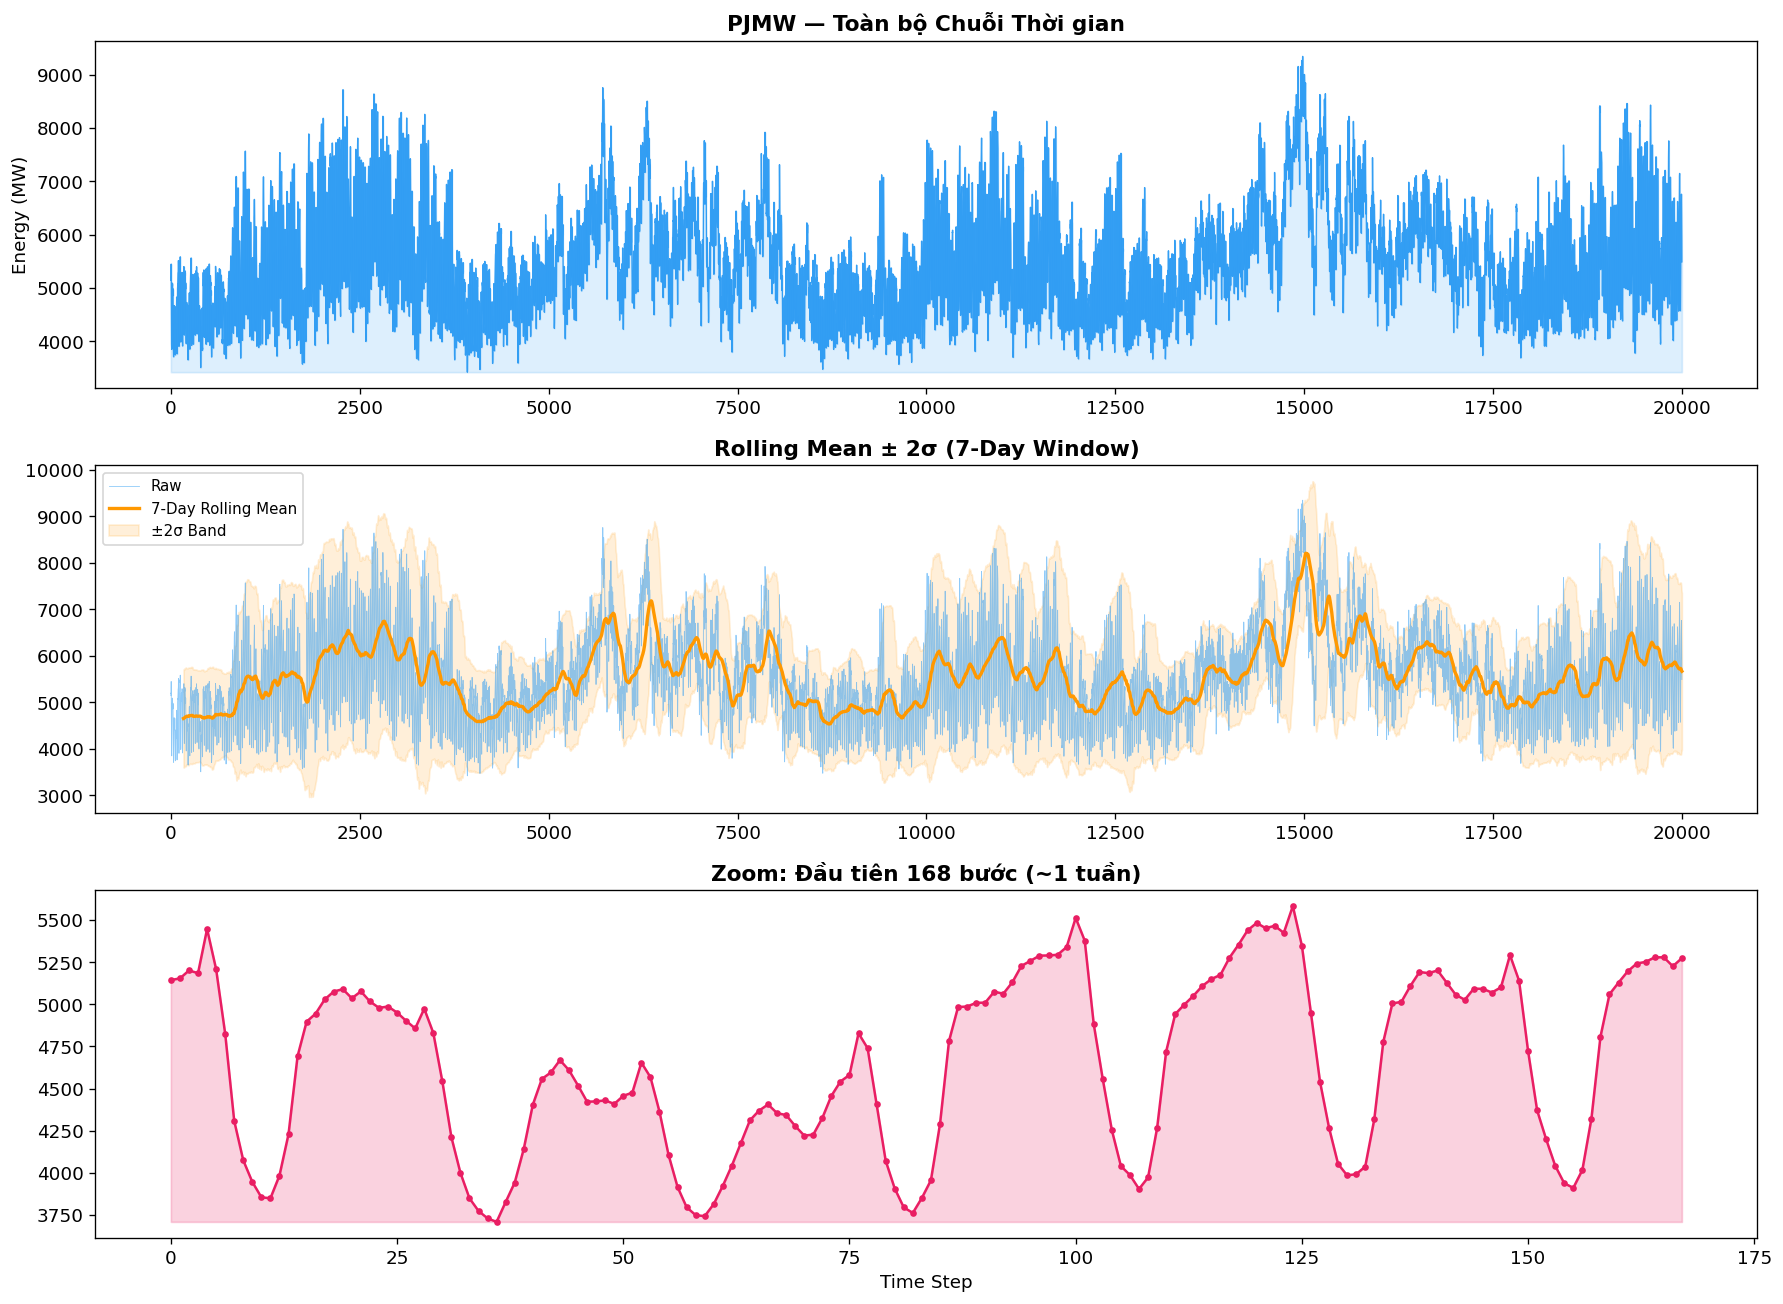

Mean: 5583.61 | Std: 1001.56 | Min: 3420.00 | Max: 9342.00


In [4]:
fig, axes = plt.subplots(3, 1, figsize=(15, 11))

# Full series
axes[0].plot(data_series, color='#2196F3', lw=0.8, alpha=0.9)
axes[0].fill_between(range(len(data_series)), data_series,
                     data_series.min(), alpha=0.15, color='#2196F3')
axes[0].set_title(f'{TARGET_COL} — Toàn bộ Chuỗi Thời gian')
axes[0].set_ylabel('Energy (MW)')

# Rolling stats
s = pd.Series(data_series)
roll_mean = s.rolling(window=168).mean()  # 7-day (168 hrs)
roll_std  = s.rolling(window=168).std()

axes[1].plot(data_series, color='#2196F3', lw=0.5, alpha=0.5, label='Raw')
axes[1].plot(roll_mean, color='#FF9800', lw=2, label='7-Day Rolling Mean')
axes[1].fill_between(range(len(data_series)),
                     (roll_mean + 2*roll_std).values,
                     (roll_mean - 2*roll_std).values,
                     alpha=0.15, color='#FF9800', label='±2σ Band')
axes[1].set_title('Rolling Mean ± 2σ (7-Day Window)')
axes[1].legend(fontsize=9)

# Zoom: 1 week
show = min(168, len(data_series))
axes[2].plot(data_series[:show], 'o-', color='#E91E63', lw=1.5, ms=3)
axes[2].fill_between(range(show), data_series[:show],
                     data_series[:show].min(), alpha=0.2, color='#E91E63')
axes[2].set_title(f'Zoom: Đầu tiên {show} bước (~1 tuần)')
axes[2].set_xlabel('Time Step')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/01_energy_eda.png', bbox_inches='tight')
plt.show()

print(f'Mean: {data_series.mean():.2f} | Std: {data_series.std():.2f} | '
      f'Min: {data_series.min():.2f} | Max: {data_series.max():.2f}')

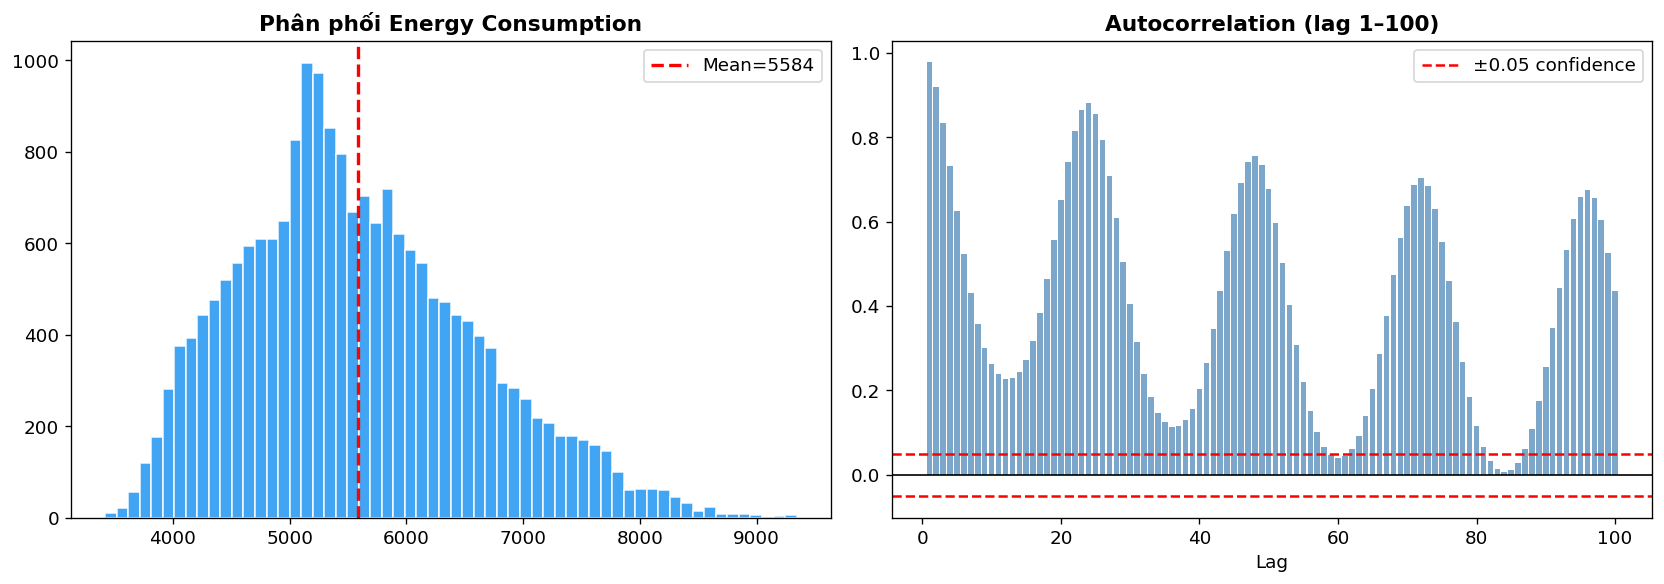

In [5]:
# Distribution + Autocorrelation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(data_series, bins=60, color='#2196F3', edgecolor='white', alpha=0.85)
axes[0].axvline(np.mean(data_series), color='red', linestyle='--', lw=2, label=f'Mean={np.mean(data_series):.0f}')
axes[0].set_title('Phân phối Energy Consumption')
axes[0].legend()

# Autocorrelation (manual)
max_lag = 100
autocorr = [pd.Series(data_series).autocorr(lag=l) for l in range(1, max_lag+1)]
axes[1].bar(range(1, max_lag+1), autocorr, color='steelblue', alpha=0.7)
axes[1].axhline(0, color='black', lw=1)
axes[1].axhline(0.05, color='red', linestyle='--', lw=1.5, label='±0.05 confidence')
axes[1].axhline(-0.05, color='red', linestyle='--', lw=1.5)
axes[1].set_title('Autocorrelation (lag 1–100)')
axes[1].set_xlabel('Lag'); axes[1].legend()

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/02_dist_autocorr.png', bbox_inches='tight')
plt.show()

## ⚙️ 3. Preprocessing & Custom Attention Layer

In [6]:
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data_series.reshape(-1,1)).flatten()

def create_dataset(data, look_back):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:i+look_back])
        y.append(data[i+look_back])
    return np.array(X), np.array(y)

X, y = create_dataset(data_scaled, LOOK_BACK)
X = X.reshape(X.shape[0], X.shape[1], 1)

split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f'X: {X.shape} → Train: {X_train.shape}, Test: {X_test.shape}')

X: (19952, 48, 1) → Train: (15961, 48, 1), Test: (3991, 48, 1)


In [7]:
# Custom Bahdanau-style Attention Layer
class AttentionLayer(layers.Layer):
    """Cơ chế Chú ý (Attention) tự xây dựng.
    
    Mô hình học cách phân bổ trọng số (attention weights) cho
    từng bước thời gian trong chuỗi đầu vào.
    """
    def __init__(self, units=64, **kwargs):
        super().__init__(**kwargs)
        self.W1 = layers.Dense(units)
        self.W2 = layers.Dense(units)
        self.V  = layers.Dense(1)

    def call(self, features):
        # features: (batch, timesteps, hidden_dim)
        score = tf.nn.tanh(self.W1(features) + self.W2(features))
        # score: (batch, timesteps, units)
        attention_weights = tf.nn.softmax(self.V(score), axis=1)
        # attention_weights: (batch, timesteps, 1)
        context = attention_weights * features
        context = tf.reduce_sum(context, axis=1)
        # context: (batch, hidden_dim)
        return context, attention_weights

print('✅ Custom Attention Layer defined')

✅ Custom Attention Layer defined


## 🏗️ 4. LSTM + Attention Model (Functional API)

In [8]:
# Build with Functional API to expose attention weights
inp = tf.keras.Input(shape=(LOOK_BACK, 1), name='input')

x = layers.LSTM(128, return_sequences=True, name='lstm_1')(inp)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
x = layers.LSTM(64, return_sequences=True, name='lstm_2')(x)
x = layers.Dropout(0.3)(x)

# Apply Attention
context, attn_weights = AttentionLayer(units=64, name='attention')(x)

x = layers.Dense(32, activation='relu')(context)
out = layers.Dense(1, name='forecast')(x)

model = tf.keras.Model(inputs=inp, outputs=out, name='LSTM_Attention_Energy')

# Separate model to extract attention weights during inference
attn_model = tf.keras.Model(inputs=inp, outputs=attn_weights, name='AttentionExtractor')

model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mse', metrics=['mae'])
model.summary()

2026-05-09 20:28:53.456497: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-09 20:28:53.458430: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-09 20:28:53.459759: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

Model: "LSTM_Attention_Energy"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input (InputLayer)          [(None, 48, 1)]           0         
                                                                 
 lstm_1 (LSTM)               (None, 48, 128)           66560     
                                                                 
 batch_normalization (Batch  (None, 48, 128)           512       
 Normalization)                                                  
                                                                 
 dropout (Dropout)           (None, 48, 128)           0         
                                                                 
 lstm_2 (LSTM)               (None, 48, 64)            49408     
                                                                 
 dropout_1 (Dropout)         (None, 48, 64)            0         
                                             

## 🚀 5. Training

In [9]:
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=7, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, min_lr=1e-7, verbose=1)
    ],
    verbose=1
)

Epoch 1/40
225/225 [==============================] - 9s 33ms/step - loss: 0.0126 - mae: 0.0835 - val_loss: 0.0802 - val_mae: 0.2488 - lr: 0.0010
Epoch 2/40
225/225 [==============================] - 7s 29ms/step - loss: 0.0060 - mae: 0.0609 - val_loss: 0.0326 - val_mae: 0.1514 - lr: 0.0010
Epoch 3/40
225/225 [==============================] - 7s 30ms/step - loss: 0.0050 - mae: 0.0555 - val_loss: 0.0306 - val_mae: 0.1429 - lr: 0.0010
Epoch 4/40
225/225 [==============================] - 7s 31ms/step - loss: 0.0045 - mae: 0.0527 - val_loss: 0.0140 - val_mae: 0.0973 - lr: 0.0010
Epoch 5/40
225/225 [==============================] - 7s 30ms/step - loss: 0.0038 - mae: 0.0483 - val_loss: 0.0063 - val_mae: 0.0638 - lr: 0.0010
Epoch 6/40
225/225 [==============================] - 7s 30ms/step - loss: 0.0033 - mae: 0.0448 - val_loss: 0.0079 - val_mae: 0.0712 - lr: 0.0010
Epoch 7/40
225/225 [==============================] - 7s 30ms/step - loss: 0.0026 - mae: 0.0398 - val_loss: 0.0057 - val_mae

## 📈 6. Evaluation + Attention Weight Heatmap

In [10]:
y_pred_s    = model.predict(X_test, verbose=0).flatten()
y_pred_orig = scaler.inverse_transform(y_pred_s.reshape(-1,1)).flatten()
y_test_orig = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
mae  = mean_absolute_error(y_test_orig, y_pred_orig)
r2   = r2_score(y_test_orig, y_pred_orig)

print(f'RMSE : {rmse:.4f} MW')
print(f'MAE  : {mae:.4f} MW')
print(f'R²   : {r2:.4f}')

RMSE : 94.1329 MW
MAE  : 74.4881 MW
R²   : 0.9884


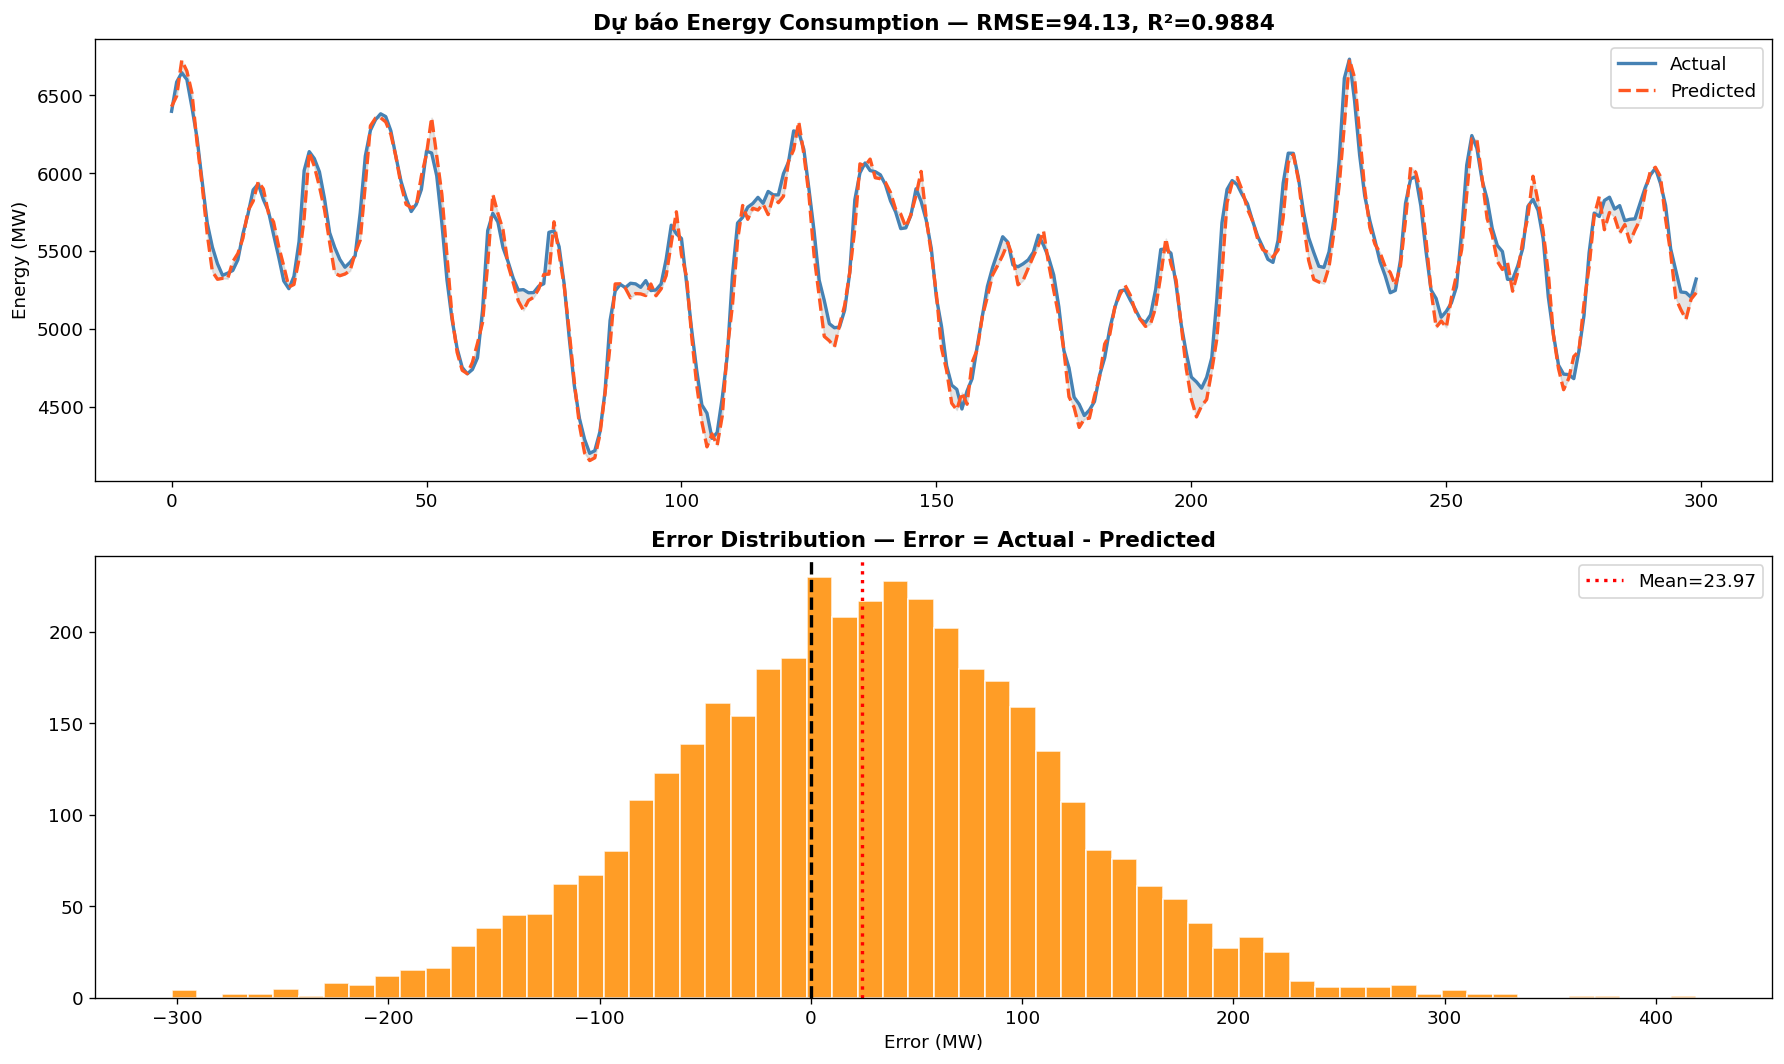

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(15, 9))

# Forecast
show_n = min(300, len(y_test_orig))
axes[0].plot(y_test_orig[:show_n], color='steelblue', lw=2, label='Actual')
axes[0].plot(y_pred_orig[:show_n], color='#FF5722', lw=2, linestyle='--', label='Predicted')
axes[0].fill_between(range(show_n), y_test_orig[:show_n], y_pred_orig[:show_n],
                     alpha=0.2, color='gray')
axes[0].set_title(f'Dự báo Energy Consumption — RMSE={rmse:.2f}, R²={r2:.4f}')
axes[0].set_ylabel('Energy (MW)')
axes[0].legend()

# Error distribution
errors = y_test_orig - y_pred_orig
axes[1].hist(errors, bins=60, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', linestyle='--', lw=2)
axes[1].axvline(errors.mean(), color='red', linestyle=':', lw=2,
                label=f'Mean={errors.mean():.2f}')
axes[1].set_title('Error Distribution — Error = Actual - Predicted')
axes[1].set_xlabel('Error (MW)')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/03_forecast_error.png', bbox_inches='tight')
plt.show()

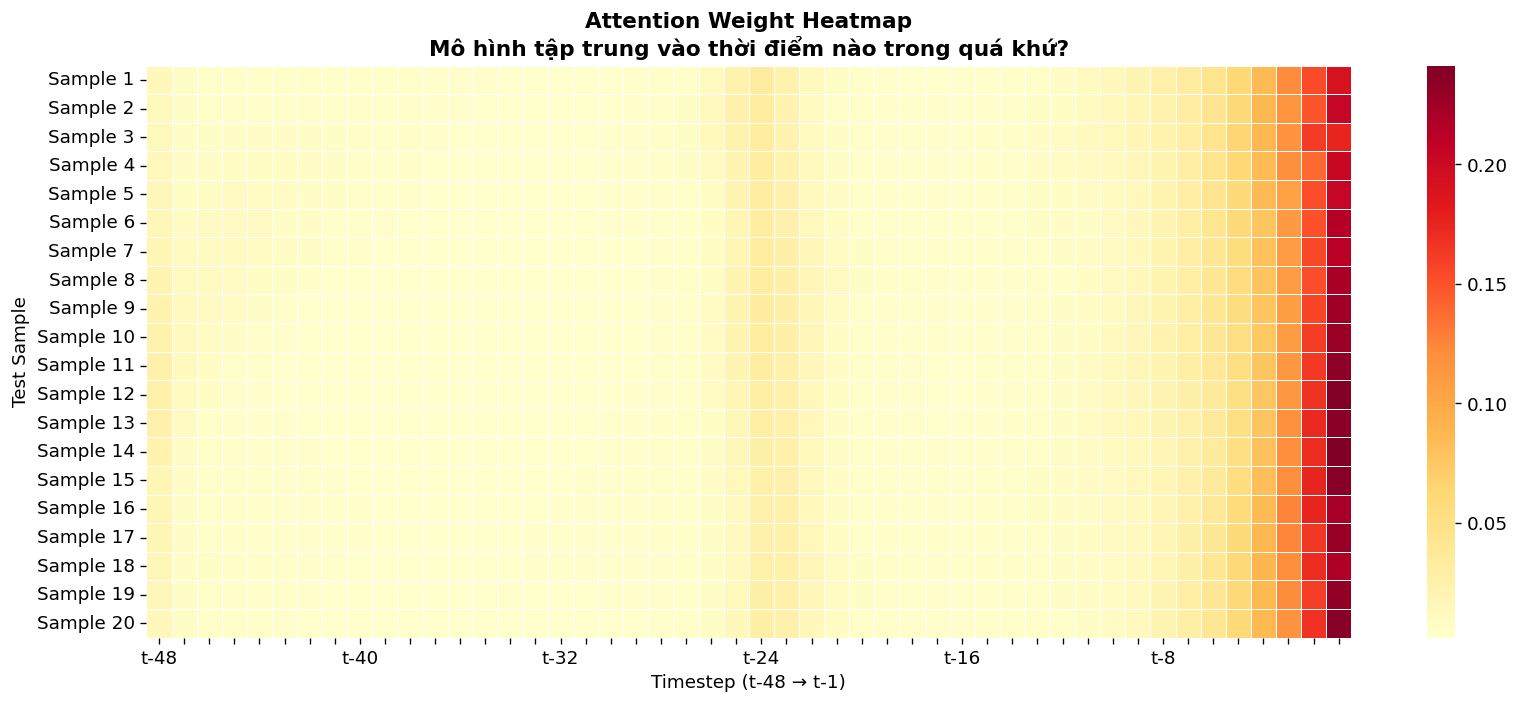


Mỗi hàng = 1 sample dự báo, màu càng đậm = Attention càng cao.
Mô hình tập trung nhiều nhất vào các bước thời gian gần nhất (t-1, t-2,...)


In [ ]:
# Attention Weight Heatmap — điểm nổi bật của notebook này
n_samples_viz = 20
sample_X  = X_test[:n_samples_viz]
attn_vals = attn_model.predict(sample_X, verbose=0)  # (n_samples, look_back, 1)
attn_vals = attn_vals.squeeze(-1)  # (n_samples, look_back)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(attn_vals, cmap='YlOrRd', ax=ax,
            xticklabels=[f't-{LOOK_BACK-i}' if i % 8 == 0 else ''
                         for i in range(LOOK_BACK)],
            yticklabels=[f'Sample {i+1}' for i in range(n_samples_viz)],
            linewidths=0.3)
ax.set_title('Attention Weight Heatmap\nMô hình tập trung vào thời điểm nào trong quá khứ?',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Timestep (t-48 → t-1)')
ax.set_ylabel('Test Sample')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/04_attention_heatmap.png', bbox_inches='tight')
plt.show()
print('\nMỗi hàng = 1 sample dự báo, màu càng đậm = Attention càng cao.')
print('Mô hình tập trung nhiều nhất vào các bước thời gian gần nhất (t-1, t-2,...)')

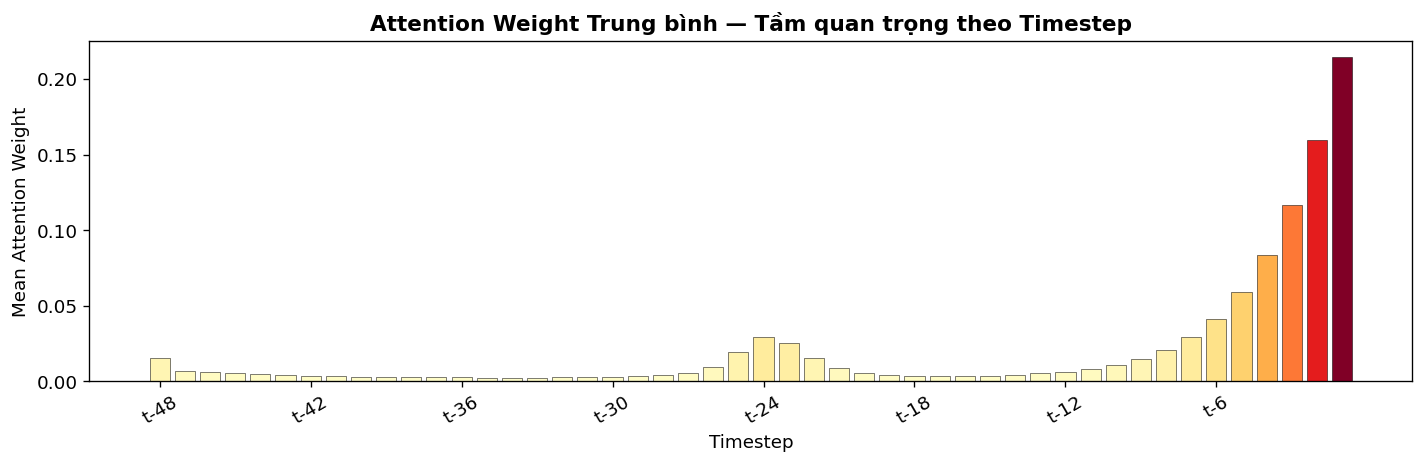

In [13]:
# Average attention over all test samples
all_attn = attn_model.predict(X_test, verbose=0).squeeze(-1)  # (N, look_back)
mean_attn = all_attn.mean(axis=0)

fig, ax = plt.subplots(figsize=(12, 4))
steps = [f't-{LOOK_BACK-i}' for i in range(LOOK_BACK)]
ax.bar(range(LOOK_BACK), mean_attn,
       color=plt.cm.YlOrRd(mean_attn / mean_attn.max()),
       edgecolor='black', linewidth=0.3)
ax.set_xticks(range(0, LOOK_BACK, 6))
ax.set_xticklabels([steps[i] for i in range(0, LOOK_BACK, 6)], rotation=30)
ax.set_title('Attention Weight Trung bình — Tầm quan trọng theo Timestep', fontweight='bold')
ax.set_xlabel('Timestep')
ax.set_ylabel('Mean Attention Weight')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/05_mean_attention.png', bbox_inches='tight')
plt.show()

In [14]:
with open(f'{SAVE_DIR}/report.txt', 'w') as f:
    f.write('Energy Consumption — LSTM + Attention\n' + '='*50 + '\n')
    f.write(f'LOOK_BACK : {LOOK_BACK} steps\n')
    f.write(f'Params    : {model.count_params():,}\n\n')
    f.write(f'Test RMSE : {rmse:.4f} MW\n')
    f.write(f'Test MAE  : {mae:.4f} MW\n')
    f.write(f'Test R²   : {r2:.4f}\n')

print('✅ Energy LSTM+Attention Done! Saved to', SAVE_DIR)

✅ Energy LSTM+Attention Done! Saved to ../results/energy_attention
